# Flashpoint - Análisis de rendimiento (Aleatorio vs A*)




In [18]:
!pip install mesa==3.5 numpy pandas matplotlib seaborn -q

In [19]:
from mesa import Agent, Model
import json
import random
import heapq
import copy
import pandas as pd
import matplotlib.pyplot as plt

## 1. Clases del dominio (GameState, Pathfinder, etc.)


In [20]:
class GameState:
    def __init__(self, data: dict):
      #Datos de cada turno
      self.turn = data.get("turn")
      self.phase = data.get("phase")
      self.current_agent_id = data.get("current_agent")
      self.game_status = data.get("game_status")

      #Tablero
      self.grid = data.get("grid")

      # Entidades
      self.poi = data.get("poi")
      self.fire = [tuple(p) for p in (data.get("fire") or [])]
      self.smoke = [tuple(p) for p in (data.get("smoke") or [])]
      self.doors = data.get("doors")
      self.damaged_walls = data.get("walls")
      self.entrances = data.get("entrances")
      #Agentes
      self.agents = data.get("agents")

      #Marcador
      self.stats = data.get("game") or {}

      # Contador acumulado de marcadores de daño colocados (para colapso del edificio).
      # Es acumulado y nunca baja, aunque una pared se destruya (regla: 24 marcadores en total).
      self.total_damage_markers = 0

    # Agente Actual
    def my_agent(self) -> dict:
      for agent in self.agents:
        if agent["id"] == self.current_agent_id:
          return agent

      return None

    #Posicion Agente
    def get_position(self, agent_id = None):
      if agent_id is None:
        agent_id = self.current_agent_id

      for agent in self.agents:
        if agent["id"] == agent_id:
          return agent["position"]

      return None

    #Tablero/Obstaculos
    def cell_walls(self,position: tuple) -> str:
      if not self.in_bounds(position):
        return None

      x, y = position
      return self.grid[y - 1][x - 1]

    def door_between(self, position1: tuple, position2: tuple) -> dict:
      for door in self.doors:
        between = door["between"]

        p1 = tuple(between[0])
        p2 = tuple(between[1])

        if (p1 == position1 and p2 == position2) or (p1 == position2 and p2 == position1):
          return door

      return None

    def damaged_wall_between(self, position1: tuple, position2: tuple) -> dict:
      for wall in self.damaged_walls:
        between = wall["between"]

        p1 = tuple(between[0])
        p2 = tuple(between[1])

        if (p1 == position1 and p2 == position2) or (p1 == position2 and p2 == position1):
          return wall

      return None

    def wall_between(self, position1: tuple, position2: tuple):
      x1, y1 = position1
      x2, y2 = position2

      cell = self.cell_walls(position1)

      if cell is None:
        return None

      if y2 == y1 - 1:
        return cell[0] == "1"

      if x2 == x1 - 1:
        return cell[1] == "1"

      if y2 == y1 + 1:
        return cell[2] == "1"

      if x2 == x1 + 1:
        return cell[3] == "1"

      return False

    def destroy_wall(self, position1: tuple, position2: tuple):
      x1, y1 = position1
      x2, y2 = position2

      cell1 = self.cell_walls(position1)
      cell2 = self.cell_walls(position2)

      if cell1 is None or cell2 is None:
        return False

      cell1 = list(cell1)
      cell2 = list(cell2)

      if y2 == y1 - 1:
          cell1[0] = "0"
          cell2[2] = "0"

      elif x2 == x1 - 1:
          cell1[1] = "0"
          cell2[3] = "0"

      elif y2 == y1 + 1:
          cell1[2] = "0"
          cell2[0] = "0"

      elif x2 == x1 + 1:
          cell1[3] = "0"
          cell2[1] = "0"

      else:
          return False

      self.grid[y1 - 1][x1 - 1] = "".join(cell1)
      self.grid[y2 - 1][x2 - 1] = "".join(cell2)

      return True

    def in_bounds(self, position: tuple) -> bool:
      x, y = position
      return 1 <= x <= len(self.grid[0]) and 1 <= y <= len(self.grid)

#--Fuego y Humo
    def is_fire(self, pos) -> bool:
      return pos in self.fire

    def is_smoke(self, pos) -> bool:
      return pos in self.smoke

    def get_fire_targets(self):
      return self.fire

    def get_smoke_targets(self):
      return self.smoke

    #POIs
    def visible_pois(self, poi):
      if poi is None:
        return None

      if poi["status"] == "known":
        return {
            "id": poi["id"],
            "position": poi["position"],
            "status": poi["status"],
            "result": poi["result"]
        }

      return {
          "id": poi["id"],
          "position": poi["position"],
          "status": poi["status"]
      }

    def poi_at(self, position):
      position = tuple(position)

      for poi in self.poi:
        if tuple(poi["position"]) == position:
          return self.visible_pois(poi)

      return None

    def get_unknown_poi(self):
      pois = []

      for poi in self.poi:
        if poi["status"] == "unknown":
          pois.append({
              "id": poi["id"],
              "position": poi["position"],
              "status": poi["status"]
          })

      return pois

    def get_known_victims(self):
      victims = []

      for poi in self.poi:
        if poi["status"] == "known":
          if poi["result"] == "victim":
            victims.append(poi)

      return victims

    def reveal_poi(self, poi_id):
      for poi in self.poi:
          if poi["id"] == poi_id:
              poi["status"] = "known"
              return poi

      return None

    def pickup_poi(self, poi_id):
      for poi in self.poi:
          if poi["id"] == poi_id:
              self.poi.remove(poi)
              return True

      return False

    # Neighbors
    def get_neighbors(self, position):
      x, y = position
      posible = [(x, y - 1), (x - 1, y), (x, y + 1), (x + 1, y)]
      neighbors = []
      for pos in posible:
        if self.in_bounds(pos):
          neighbors.append(pos)
      return neighbors

    # Adyacencia real de juego (respeta puertas cerradas y paredes no destruidas).
    # Mismo criterio que Bombero.puede_actuar_sobre, reutilizado por el motor de fuego.
    def son_adyacentes(self, position1, position2):
      if position2 not in self.get_neighbors(position1):
        return False

      door = self.door_between(position1, position2)
      if door and door["status"] == "closed":
        return False

      if self.damaged_wall_between(position1, position2):
        return False

      if self.wall_between(position1, position2):
        return False

      return True

    # Coloca un marcador de daño entre dos celdas: crea el primer daño o destruye
    # la pared en el segundo daño. Usado tanto por ActionBuilder.damage_wall (hachar)
    # como por el motor de fuego (explosiones/shockwaves), para que el conteo
    # acumulado de marcadores (tope de 24 -> colapso) quede en un solo lugar.
    def place_damage_marker(self, position1, position2):
      damaged_wall = self.damaged_wall_between(position1, position2)

      if damaged_wall:
        self.damaged_walls.remove(damaged_wall)
        self.destroy_wall(position1, position2)
      else:
        self.damaged_walls.append({
            "id": len(self.damaged_walls) + random.randint(100, 1000),
            "between": [list(position1), list(position2)]
        })

      self.total_damage_markers += 1

In [21]:
class PriorityQueue:
    def __init__(self):
        self.__data = []

    def empty(self):
        return not self.__data

    def clear(self):
        self.__data.clear()

    def push(self, priority, value):
        heapq.heappush(self.__data, (priority, value))

    def pop(self):
        if self.__data:
            return heapq.heappop(self.__data)
        else:
            raise Exception("No such element")

    def top(self):
        if self.__data:
            return self.__data[0]
        else:
            raise Exception("No such element")


class Pathfinder:
    COST_MOVE = 1
    COST_MOVE_FIRE = 2
    COST_SMOKE = 1
    COST_OPEN_DOOR = 1
    COST_DAMAGE_WALL = 2
    COST_CARRY_VICTIM = 2
    COST_EXTINGUISH_FIRE = 1
    COST_CLEAR_SMOKE = 1

    BLOCKED = float("inf")
    def __init__(self, state: GameState):
        self.state = state

    def heuristica(self, pos, goal):
      return (abs(pos[0] - goal[0]) + abs(pos[1] - goal[1]) )* self.COST_MOVE

    def costo_celda(self, pos, cargando_victima = False):
      if cargando_victima and self.state.is_fire(pos):
        return self.BLOCKED

      if cargando_victima:
        return self.COST_CARRY_VICTIM

      if self.state.is_fire(pos):
        return self.COST_MOVE_FIRE

      if self.state.is_smoke(pos):
        return self.COST_SMOKE

      return self.COST_MOVE

    def costo_borde(self, u, v, cargando_victima = False):
      costo_celda = self.costo_celda(v, cargando_victima)

      if costo_celda == self.BLOCKED:
        return self.BLOCKED

      door = self.state.door_between(u,v)

      if door:
        if door["status"] in ["open", "destroyed"]:
          return self.costo_celda(v, cargando_victima)

        return self.COST_OPEN_DOOR + self.costo_celda(v, cargando_victima)

      wall = self.state.damaged_wall_between(u,v)

      if wall:
        return self.COST_DAMAGE_WALL + self.costo_celda(v, cargando_victima)

      if self.state.wall_between(u,v):
        return (2*self.COST_DAMAGE_WALL) + self.costo_celda(v, cargando_victima)

      return self.costo_celda(v, cargando_victima)

    def a_estrella(self, start, goal, cargando_victima = False):
      dist = {start:0}
      prev = {}

      prioridad = self.heuristica(start,goal)

      pq = PriorityQueue()
      pq.push(prioridad, start)
      steps = 0

      while not pq.empty():
        priority, u = pq.pop()

        if u == goal:
          break

        for v in self.state.get_neighbors(u):
          cost = self.costo_borde(u, v, cargando_victima)
          if cost >= self.BLOCKED:
            continue

          new_dist = dist[u] + cost

          if new_dist < dist.get(v, self.BLOCKED):
            dist[v] = new_dist
            prev[v] = u
            priority = new_dist + self.heuristica(v,goal)
            pq.push(priority, v)
        steps += 1

      path = []
      u = goal
      if prev.get(u) is not None or u == start:
        while u is not None:
          path.insert(0,u)
          u = prev.get(u)

      return (dist.get(goal, self.BLOCKED), path, steps)

    def find_path(self, start, goal, cargando_victima = False):
      return self.a_estrella(start,goal, cargando_victima)

In [22]:
class ReservationManager:
    def __init__(self):
        self.reservations = {}

    def is_reserved(self, target_type, target_id, by_agent=None):
        key = (target_type, target_id)
        if key not in self.reservations:
            return False

        owner = self.reservations[key]

        if owner != None:
          return owner != by_agent

        return True

    def has_reservation(self, agent_id = None):
      for key, owner in self.reservations.items():
        if owner == agent_id:
          return key

      return None

    def reserve(self, target_type, target_id, agent_id):
        key = (target_type, target_id)
        if key in self.reservations:
            return False

        self.reservations[key] = agent_id
        return True

    def release(self, target_type, target_id):
        key = (target_type, target_id)
        if key in self.reservations:
            del self.reservations[key]

## 2. `ActionBuilder`



In [23]:
class ActionBuilder:
    def __init__(self, agent_id, starting_ap, state):
        self.state = state
        self.agent_id = agent_id
        self.remaining_ap = starting_ap
        self.actions = []

    def puede_pagar(self, cost):
        return cost <= self.remaining_ap

    def fire_to_smoke(self, position, cost = 1):
        if not self.puede_pagar(cost):
            return False

        if position not in self.state.fire:
            return False

        self.remaining_ap -= cost

        self.actions.append({
            "order": len(self.actions) + 1,
            "type": "extinguish_fire",
            "position": list(position),
            "cost": cost,
            "remaining_ap": self.remaining_ap
        })

        self.state.fire.remove(position)

        if position not in self.state.smoke:
            self.state.smoke.append(position)

        return True

    def move(self, from_pos, to_pos, cost=1):
        if cost > self.remaining_ap:
            return False

        self.remaining_ap -= cost
        self.actions.append({
            "order": len(self.actions) + 1,
            "type": "move",
            "from": from_pos,
            "to": to_pos,
            "cost": cost,
            "remaining_ap": self.remaining_ap
        })

        agente = self.state.my_agent()  # NUEVO
        if agente is not None:  # NUEVO
            agente["position"] = list(to_pos)  # NUEVO

        return True

    def open_door(self,between, cost = 1):
      if not self.puede_pagar(cost):
        return False

      self.remaining_ap -= cost
      self.actions.append({
          "order": len(self.actions) + 1,
          "id": self.state.door_between(between[0], between[1])["id"],
          "type": "open_door",
          "between": [list(between[0]), list(between[1])],
          "cost": cost,
          "remaining_ap": self.remaining_ap
      })

      door = self.state.door_between(between[0], between[1])
      if door:
          door["status"] = "open"

      return True

    def clear_smoke(self, position, cost = 1):
      if not self.puede_pagar(cost):
        return False
      self.remaining_ap -= cost
      self.actions.append({
          "order": len(self.actions) + 1,
          "type": "clear_smoke",
          "position": list(position),
          "cost": cost,
          "remaining_ap": self.remaining_ap
      })

      if position in self.state.smoke:
          self.state.smoke.remove(position)

      return True

    def damage_wall(self, between, cost = 2):
      if not self.puede_pagar(cost):
        return False
      self.remaining_ap -= cost
      self.actions.append({
          "order": len(self.actions) + 1,
          "type": "damage_Wall",
          "between": [list(between[0]), list(between[1])],
          "cost": cost,
          "remaining_ap": self.remaining_ap
      })

      self.state.place_damage_marker(between[0], between[1])  # NUEVO: lleva la cuenta acumulada para el colapso

      return True

    def pickup_victim(self, poi_id, position):
      if not self.state.pickup_poi(poi_id):
          return False
      self.actions.append({
          "order": len(self.actions) + 1,
          "type": "pickup_victim",
          "poi_id": poi_id,
          "position": list(position),
          "cost": 0,
          "remaining_ap": self.remaining_ap
      })

      self.state.my_agent()["carrying_victim"] = True
      return True

    def move_with_victim(self, from_pos, to_pos, cost = 2):
      if not self.puede_pagar(cost):
        return False
      self.remaining_ap -= cost
      self.actions.append({
          "order": len(self.actions) + 1,
          "type": "move_with_victim",
          "from": from_pos,
          "to": to_pos,
          "cost": cost,
          "remaining_ap": self.remaining_ap
      })

      agente = self.state.my_agent()  # NUEVO
      if agente is not None:  # NUEVO
          agente["position"] = list(to_pos)  # NUEVO

      return True

    def reveal_poi(self, poi_id, position):
      self.actions.append({
          "order": len(self.actions) + 1,
          "type": "reveal_poi",
          "poi_id": poi_id,
          "position": list(position),
          "cost": 0,
          "remaining_ap": self.remaining_ap
      })

      return True

    def rescue_victim(self, position):
        self.actions.append({
            "order": len(self.actions) + 1,
            "type": "rescue_victim",
            "position": list(position),
            "cost": 0,
            "remaining_ap": self.remaining_ap
        })

        self.state.my_agent()["carrying_victim"] = False
        self.state.stats["rescued"] = self.state.stats.get("rescued", 0) + 1  # NUEVO: antes no se contaba

        return True

    def build(self):
      return {"agent_id": self.agent_id, "actions": self.actions}

In [24]:
class Bombero(Agent):
    AP = 4

    def __init__(self, model, state, pathfinder, reservations):
        super().__init__(model)
        self.state = state
        self.pathfinder = pathfinder
        self.reservations = reservations
        self.pos_actual = tuple(state.my_agent()["position"])
        self.cargando_victima = state.my_agent()["carrying_victim"]
        self.builder = ActionBuilder(agent_id = state.my_agent()["id"], starting_ap = state.my_agent()["ap"], state = state)

    def sensor_celda_actual(self):
        celda_actual = {
            "poi": self.state.poi_at(self.pos_actual),
            "fire": self.state.is_fire(self.pos_actual),
            "smoke": self.state.is_smoke(self.pos_actual)
        }
        return celda_actual

    def sensor_vecindario(self):
        vecinos = []

        for pos in self.state.get_neighbors(self.pos_actual):
            vecinos.append({
                "position": pos,
                "poi": self.state.poi_at(pos),
                "fire": self.state.is_fire(pos),
                "smoke": self.state.is_smoke(pos),
                "door": self.state.door_between(self.pos_actual, pos),
                "damaged_wall": self.state.damaged_wall_between(self.pos_actual, pos)
            })

        return vecinos

    def puede_actuar_sobre(self, posicion):
        if posicion not in self.state.get_neighbors(self.pos_actual):
            return False

        door = self.state.door_between(self.pos_actual, posicion)
        if door and door["status"] == "closed":
            return False

        damaged_wall = self.state.damaged_wall_between(self.pos_actual, posicion)
        if damaged_wall:
            return False

        if self.state.wall_between(self.pos_actual, posicion):
            return False

        return True

    def puede_atravesar_fuego(self, siguiente):
        if self.cargando_victima:
            return False

        if not self.state.is_fire(siguiente):
            return True

        costo_entrada = self.pathfinder.costo_borde(self.pos_actual, siguiente, cargando_victima = False)

        if self.pathfinder.BLOCKED <= costo_entrada:
            return False

        if self.builder.remaining_ap < costo_entrada:
            return False

        ap_despues = self.builder.remaining_ap - costo_entrada

        for salida in self.state.get_neighbors(siguiente):
            if self.state.is_fire(salida):
                continue

            costo_salida = self.pathfinder.costo_borde(siguiente, salida, cargando_victima = False)

            if costo_salida <= ap_despues:
                return True

        return False

    def _salir_de_fuego(self):
      opciones = []

      for vecino in self.state.get_neighbors(self.pos_actual):
          if self.state.is_fire(vecino):
              continue

          costo = self.pathfinder.costo_borde(self.pos_actual, vecino, cargando_victima = False)

          if costo <= self.builder.remaining_ap:
              opciones.append((costo, vecino))

      if not opciones:
          return False

      costo, vecino = min(opciones, key = lambda x: x[0])

      return self._cruzar_a(vecino)

    def decide(self):
        while self.builder.remaining_ap > 0:
            if not self._siguiente_accion():
                break
        return self.builder.build()

    def _siguiente_accion(self):
        if self.cargando_victima:
            return self._avanzar_a_salida()

        if self.state.is_fire(self.pos_actual):
            return self._salir_de_fuego()

        poi_aqui = self.sensor_celda_actual()["poi"]

        if poi_aqui:
            if poi_aqui["status"] == "unknown":
                poi_real = self.state.reveal_poi(poi_aqui["id"])
                self.builder.reveal_poi(poi_real["id"], poi_real["position"])
            else:
                poi_real = poi_aqui

            if poi_real["result"] == "victim":
                return self._recoger_aqui(poi_real)

            if poi_real["result"] == "false_alarm":
                self.reservations.release("poi", poi_real["id"])
                return False

        for fire in self.state.get_fire_targets():
            if self.puede_actuar_sobre(fire):
              exito = self._atender_fuego(fire)
              if exito:
                  self.reservations.release("fire", tuple(fire))
                  self.reservations.reserve("smoke", tuple(fire), self.state.my_agent()["id"])

              return exito

        for smoke in self.state.get_smoke_targets():
            if self.puede_actuar_sobre(smoke):
                exito = self._atender_humo(smoke)
                if exito:
                    self.reservations.release("smoke", tuple(smoke))

                return exito

        objetivo = self._elegir_objetivo()
        if objetivo is None:
            return False

        return self._avanzar_hacia(tuple(objetivo))

    def _elegir_objetivo(self):
        agent_id = self.state.my_agent()["id"]

        reserva = self.reservations.has_reservation(agent_id)
        if reserva:
            target_type, target_id = reserva
            if target_type == "poi":
                for poi in self.state.poi:
                    if poi["id"] == target_id:
                        return poi["position"]

            elif target_type == "fire":
                target = tuple(target_id)
                if target in self.state.get_fire_targets():
                    return target
                self.reservations.release("fire", target)

            elif target_type == "smoke":
                target = tuple(target_id)
                if target in self.state.get_smoke_targets():
                    return target
                self.reservations.release("smoke", target)

        for poi in self.state.get_known_victims():
            if not self.reservations.is_reserved("poi", poi["id"], by_agent = agent_id):
                self.reservations.reserve("poi", poi["id"], agent_id)
                return poi["position"]

        for poi in self.state.get_unknown_poi():
            if not self.reservations.is_reserved("poi", poi["id"], by_agent = agent_id):
                self.reservations.reserve("poi", poi["id"], agent_id)
                return poi["position"]

        close_fires = sorted(
            self.state.get_fire_targets(),
            key=lambda e: self.pathfinder.a_estrella(self.pos_actual, tuple(e))[0]
         )
        for fire in close_fires:
            if not self.reservations.is_reserved("fire", tuple(fire), by_agent = agent_id):
                    self.reservations.reserve("fire", tuple(fire), agent_id)
                    return fire

        close_smokes = sorted(
            self.state.get_smoke_targets(),
            key=lambda e: self.pathfinder.a_estrella(self.pos_actual, tuple(e))[0]
        )
        for smoke in close_smokes:
            if not self.reservations.is_reserved("smoke", tuple(smoke), by_agent = agent_id):
                self.reservations.reserve("smoke", tuple(smoke), agent_id)
                return smoke

        return None

    def _avanzar_hacia(self, goal):
        cost, path, steps = self.pathfinder.find_path(self.pos_actual, goal, self.cargando_victima)

        if cost == self.pathfinder.BLOCKED:
            return False

        if len(path) < 2:
            return False

        return self._cruzar_a(path[1])

    def _cruzar_a(self, siguiente):
        if self.cargando_victima and self.state.is_fire(siguiente):
            return False

        if not self.cargando_victima and self.state.is_fire(siguiente):
            if not self.puede_atravesar_fuego(siguiente):
                return False

        between = [self.pos_actual, siguiente]

        door = self.state.door_between(self.pos_actual, siguiente)
        if door:
            if door["status"] == "closed":
                return self.builder.open_door(between, cost = self.pathfinder.COST_OPEN_DOOR)

        damaged_wall = self.state.damaged_wall_between(self.pos_actual, siguiente)
        if damaged_wall:
            return self.builder.damage_wall(between, cost = self.pathfinder.COST_DAMAGE_WALL)

        wall = self.state.wall_between(self.pos_actual, siguiente)
        if wall:
            return self.builder.damage_wall(between, cost = self.pathfinder.COST_DAMAGE_WALL)

        if self.cargando_victima:
            exito = self.builder.move_with_victim(self.pos_actual, siguiente, cost = self.pathfinder.COST_CARRY_VICTIM)
            if exito:
                self.pos_actual = siguiente
            return exito

        cost = self.pathfinder.costo_celda(siguiente, self.cargando_victima)

        if not self.builder.puede_pagar(cost):
            return False

        exito = self.builder.move(self.pos_actual, siguiente, cost)

        if exito:
            self.pos_actual = siguiente

        return exito

    def _recoger_aqui(self, poi):
        exito = self.builder.pickup_victim(poi["id"], self.pos_actual)
        if exito:
            self.cargando_victima = True
            self.reservations.release("poi", poi["id"])
        return exito

    def _avanzar_a_salida(self):
        salidas_posibles = []

        for entrada in self.state.entrances:
            cost, path, steps = self.pathfinder.find_path(self.pos_actual, tuple(entrada), self.cargando_victima)
            if cost < self.pathfinder.BLOCKED:
                salidas_posibles.append((cost, path))

        if not salidas_posibles:
            return False

        costo_salida, camino_salida = min(salidas_posibles, key = lambda x: x[0])

        if self.pos_actual == tuple(camino_salida[-1]):
            self.cargando_victima = False
            return self.builder.rescue_victim(self.pos_actual)

        return self._avanzar_hacia(tuple(camino_salida[-1]))

    def _atender_fuego(self, position):
        return self.builder.fire_to_smoke(position, cost = self.pathfinder.COST_EXTINGUISH_FIRE)

    def _atender_humo(self, position):
        return self.builder.clear_smoke(position, cost = self.pathfinder.COST_CLEAR_SMOKE)

    def step(self):
        return self.decide()

## 3. Agente aleatorio (nuevo)

In [25]:
class BomberoAleatorio(Bombero):
    def _siguiente_accion(self):
        vecinos = self.state.get_neighbors(self.pos_actual)
        if not vecinos:
            return False

        siguiente = random.choice(vecinos)
        return self._cruzar_a(siguiente)

In [26]:
class FlashpointModel(Model):
    def __init__(self):
        super().__init__()
        self.bomberos = {}

    def get_or_create_bombero(self, agent_id, state, pathfinder, reservations, clase = None):
        clase = clase or Bombero
        if agent_id not in self.bomberos or type(self.bomberos[agent_id]) is not clase:
            bombero = clase(model = self, state = state, pathfinder = pathfinder, reservations = reservations)
            self.bomberos[agent_id] = bombero
        else:
            bombero = self.bomberos[agent_id]
            bombero.state = state
            bombero.pathfinder = pathfinder
            bombero.pos_actual = tuple(state.my_agent()["position"])
            bombero.cargando_victima = state.my_agent()["carrying_victim"]
            bombero.builder = ActionBuilder(agent_id = agent_id, starting_ap = state.my_agent()["ap"], state = state)
        return bombero

## 4. Motor de avance de fuego (`AdvanceFireEngine`)



In [27]:
class AdvanceFireEngine:
    NORTE, OESTE, SUR, ESTE = (0, -1), (-1, 0), (0, 1), (1, 0)
    DIRECCIONES = [NORTE, OESTE, SUR, ESTE]

    def __init__(self, state, rng = None):
        self.state = state
        self.rng = rng or random

    def _tirar_objetivo(self):
        num_filas = len(self.state.grid)
        num_columnas = len(self.state.grid[0])
        fila = self.rng.randint(1, num_filas)      # dado rojo (d6)
        columna = self.rng.randint(1, num_columnas)  # dado negro (d8)
        return (columna, fila)

    # --- Fase 2: Advance Fire ---
    def avanzar(self):
        objetivo = self._tirar_objetivo()
        self._resolver_objetivo(objetivo)
        self._resolver_flashover()
        self._resolver_efectos_secundarios()

    def _resolver_objetivo(self, pos):
        if self.state.is_fire(pos):
            self._explosion(pos)
        elif self.state.is_smoke(pos):
            self.state.smoke.remove(pos)
            self.state.fire.append(pos)
        else:
            self.state.smoke.append(pos)

    def _explosion(self, origen):
        for direccion in self.DIRECCIONES:
            self._explosion_direccion(origen, direccion)

    def _explosion_direccion(self, u, direccion):
        dx, dy = direccion
        v = (u[0] + dx, u[1] + dy)

        puerta = self.state.door_between(u, v)
        if puerta:
            if puerta["status"] == "closed":
                self.state.doors.remove(puerta)  # puerta destruida, la explosión no sigue de largo
                return
            self.state.doors.remove(puerta)  # puerta abierta: se destruye y la onda sigue
            self._propagar(v, direccion)
            return

        if self.state.wall_between(u, v):
            self.state.place_damage_marker(u, v)
            return

        self._propagar(v, direccion)

    def _propagar(self, pos, direccion):
        if not self.state.in_bounds(pos):
            # Fuego "fuera" del edificio: se limpia en los efectos secundarios
            if pos not in self.state.fire:
                self.state.fire.append(pos)
            return

        if self.state.is_fire(pos):
            self._avanzar_shockwave(pos, direccion)
            return

        if self.state.is_smoke(pos):
            self.state.smoke.remove(pos)
            self.state.fire.append(pos)
            return

        self.state.fire.append(pos)

    def _avanzar_shockwave(self, pos, direccion):
        dx, dy = direccion
        siguiente = (pos[0] + dx, pos[1] + dy)

        puerta = self.state.door_between(pos, siguiente)
        if puerta:
            self.state.doors.remove(puerta)
            if puerta["status"] == "closed":
                return  # puerta cerrada detiene la onda (y queda destruida)
            self._propagar(siguiente, direccion)  # puerta abierta: la onda sigue
            return

        if self.state.wall_between(pos, siguiente):
            self.state.place_damage_marker(pos, siguiente)
            return

        self._propagar(siguiente, direccion)

    # --- Flashover: todo humo adyacente a fuego se vuelve fuego, hasta que no quede ninguno ---
    def _resolver_flashover(self):
        cambiado = True
        while cambiado:
            cambiado = False
            for smoke_pos in list(self.state.smoke):
                for fire_pos in self.state.fire:
                    if self.state.son_adyacentes(smoke_pos, fire_pos):
                        self.state.smoke.remove(smoke_pos)
                        self.state.fire.append(smoke_pos)
                        cambiado = True
                        break
                if cambiado:
                    break

    # --- Noqueos, víctimas/POI perdidos, limpieza de fuego fuera del tablero ---
    def _resolver_efectos_secundarios(self):
        self.state.fire = [p for p in self.state.fire if self.state.in_bounds(p)]

        for poi in list(self.state.poi):
            if tuple(poi["position"]) in self.state.fire:
                if poi.get("result") == "victim":
                    self.state.stats["lost"] = self.state.stats.get("lost", 0) + 1
                self.state.poi.remove(poi)

        for agente in self.state.agents:
            pos = tuple(agente["position"])
            if pos in self.state.fire:
                if agente.get("carrying_victim"):
                    self.state.stats["lost"] = self.state.stats.get("lost", 0) + 1
                    agente["carrying_victim"] = False

                salida = self._salida_mas_cercana(pos)
                if salida is not None:
                    agente["position"] = list(salida)

    def _salida_mas_cercana(self, pos):
        # Aproximación: usamos las entradas del edificio como Ambulance Parking Spot
        # (ver nota al inicio del notebook).
        entradas = self.state.entrances or []
        if not entradas:
            return None
        return min(
            (tuple(e) for e in entradas),
            key = lambda e: (e[0] - pos[0]) ** 2 + (e[1] - pos[1]) ** 2
        )

    # --- Fase 3: Replenish POI ---
    def replenish_poi(self, proba_victima = 10 / 15):
        intentos = 0
        while len(self.state.poi) < 3 and intentos < 300:
            intentos += 1
            pos = self._tirar_objetivo()

            if pos in self.state.fire or pos in self.state.smoke:
                continue
            if any(tuple(p["position"]) == pos for p in self.state.poi):
                continue

            resultado = "victim" if self.rng.random() < proba_victima else "false_alarm"
            nuevo_poi = {
                "id": f"poi_{self.rng.randint(10000, 99999)}",
                "position": list(pos),
                "status": "unknown",
                "result": resultado,
            }

            ocupado_por_bombero = any(tuple(a["position"]) == pos for a in self.state.agents)
            if ocupado_por_bombero:
                if resultado == "false_alarm":
                    continue  # se revela y se descarta de inmediato, no ocupa un lugar
                nuevo_poi["status"] = "known"

            self.state.poi.append(nuevo_poi)

## 5. Cargar `Initial_State.json`



In [28]:
def cargar_estado_inicial(ruta_json):
    with open(ruta_json, "r", encoding="utf-8") as f:
        return json.load(f)

data_inicial = cargar_estado_inicial("Initial_State.json")

## 6. Simulación por lotes (con fuego avanzando)

Cada iteración del loop es el turno de UN agente: 1) Take Action (`bombero.decide()`), 2) Advance Fire (`fuego.avanzar()`), 3) Replenish POI (`fuego.replenish_poi()`) — igual que el orden real del juego. La partida termina en victoria (7 rescatados), derrota (4 perdidos) o colapso (24 marcadores de daño acumulados); si no pasa nada de eso en `max_turnos`, queda "en_progreso" (timeout).

In [29]:
def simular_partida(data_inicial, clase_bombero, seed, max_turnos = 200):
    random.seed(seed)             # mueve al agente aleatorio (y genera ids de pared, sin efecto en el resultado)
    fire_rng = random.Random(seed)  # controla el fuego, aislado del agente para poder comparar con semillas pareadas

    data = copy.deepcopy(data_inicial)
    state = GameState(data)
    state.stats.setdefault("rescued", 0)
    state.stats.setdefault("lost", 0)

    pathfinder = Pathfinder(state)
    reservations = ReservationManager()
    modelo = FlashpointModel()
    fuego = AdvanceFireEngine(state, rng = fire_rng)

    metricas = {
        "turnos_jugados": 0,
        "rescatados_final": 0,
        "perdidos_final": 0,
        "danio_final": 0,
        "turno_primer_rescate": None,
        "movimientos_desperdiciados": 0,
        "distancia_total": 0,
        "resultado": "en_progreso",
    }

    agentes_ids = [a["id"] for a in data["agents"]]
    turno_actual = 0

    for turno in range(max_turnos):
        agent_id = agentes_ids[turno_actual % len(agentes_ids)]
        state.current_agent_id = agent_id

        bombero = modelo.get_or_create_bombero(agent_id, state, pathfinder, reservations, clase = clase_bombero)
        resultado_turno = bombero.decide()

        movimientos = [a for a in resultado_turno["actions"] if a["type"] in ("move", "move_with_victim")]
        metricas["distancia_total"] += len(movimientos)
        if not resultado_turno["actions"]:
            metricas["movimientos_desperdiciados"] += 1

        fuego.avanzar()
        fuego.replenish_poi()

        metricas["turnos_jugados"] = turno + 1

        if state.stats["rescued"] > 0 and metricas["turno_primer_rescate"] is None:
            metricas["turno_primer_rescate"] = turno + 1

        if state.total_damage_markers >= 24:
            metricas["resultado"] = "colapso"
            break
        if state.stats["rescued"] >= 7:
            metricas["resultado"] = "victoria"
            break
        if state.stats["lost"] >= 4:
            metricas["resultado"] = "derrota"
            break

        turno_actual += 1

    metricas["rescatados_final"] = state.stats.get("rescued", 0)
    metricas["perdidos_final"] = state.stats.get("lost", 0)
    metricas["danio_final"] = state.total_damage_markers

    return metricas

## 7. Correr varias semillas y comparar (semillas pareadas)

Para cada semilla, ambos agentes enfrentan exactamente la misma secuencia de tiradas de fuego (por el `fire_rng` aislado). Así cualquier diferencia en el resultado es atribuible a la decisión del agente, no a que a uno le tocó un fuego más benigno.

In [30]:
N_CORRIDAS = 200

filas = []

for seed in range(N_CORRIDAS):
    for clase, nombre in [(BomberoAleatorio, "Aleatorio"), (Bombero, "Inteligente (A*)")]:
        m = simular_partida(data_inicial, clase, seed = seed)
        m["agente"] = nombre
        m["seed"] = seed
        filas.append(m)

df = pd.DataFrame(filas)
df.head()

,turnos_jugados,rescatados_final,perdidos_final,danio_final,turno_primer_rescate,movimientos_desperdiciados,distancia_total,resultado,agente,seed
0,23,0,1,25,NaN,5,59,colapso,Aleatorio,0
1,53,7,2,15,25.0,4,94,victoria,Inteligente (A*),0
2,23,0,3,25,NaN,5,48,colapso,Aleatorio,1
3,39,1,0,24,27.0,11,54,colapso,Inteligente (A*),1
4,29,0,2,24,NaN,8,53,colapso,Aleatorio,2


## 8. Métricas que sí dependen de la calidad de la decisión

En vez de solo promediar rescatados/perdidos/daño (que ahora sí se mueven con el fuego, pero conviene verlos junto con el desenlace de la partida), la tabla de abajo se enfoca en:

- **Tasa de victoria / derrota / colapso / timeout** —\
- **Turno del primer rescate** — qué tan rápido cada agente empieza a resolver el objetivo.
- **Movimientos desperdiciados por turno jugado** — proporción de turnos donde el agente no logró ninguna acción (se quedó atorado).
- **Distancia recorrida** — cuántos pasos de movimiento le tomó a cada agente, en promedio.

In [31]:
tasa_resultado = (
    df.groupby(["agente", "resultado"]).size().unstack(fill_value = 0) / N_CORRIDAS * 100
).round(1)

resumen = df.groupby("agente").agg(
    turnos_jugados = ("turnos_jugados", "mean"),
    rescatados_final = ("rescatados_final", "mean"),
    perdidos_final = ("perdidos_final", "mean"),
    danio_final = ("danio_final", "mean"),
    turno_primer_rescate = ("turno_primer_rescate", "mean"),
    distancia_total = ("distancia_total", "mean"),
).round(2)
resumen["desperdicio_por_turno"] = (df["movimientos_desperdiciados"] / df["turnos_jugados"]).groupby(df["agente"]).mean().round(3)

print("Resultado de la partida (% de corridas):")
display(tasa_resultado)

print("\nPromedios por partida:")
display(resumen)

Resultado de la partida (% de corridas):


resultado,colapso,derrota,victoria
agente,,,
Aleatorio,97.0,3.0,0.0
Inteligente (A*),85.0,6.0,9.0



Promedios por partida:


,turnos_jugados,rescatados_final,perdidos_final,danio_final,turno_primer_rescate,distancia_total,desperdicio_por_turno
agente,,,,,,,
Aleatorio,21.72,0.00,1.19,24.80,NaN,53.18,0.121
Inteligente (A*),49.08,3.52,1.56,23.46,24.26,69.39,0.215


## 9. Gráficas comparativas

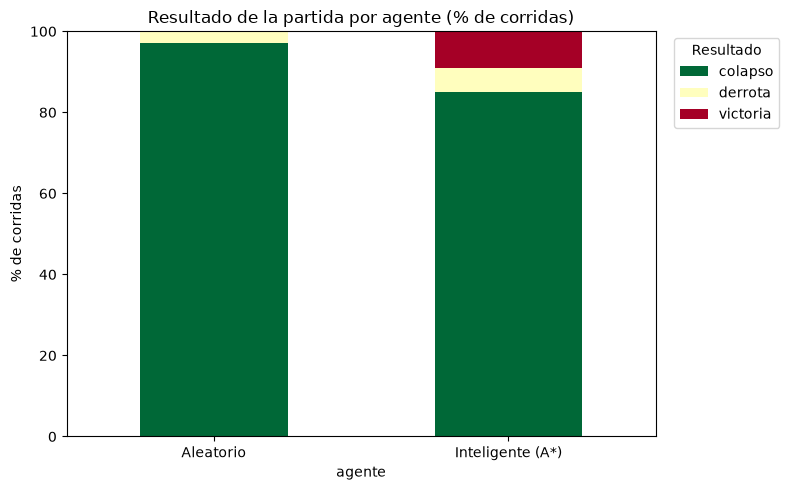

In [32]:
tasa_resultado.plot(kind = "bar", stacked = True, figsize = (8, 5), colormap = "RdYlGn_r")
plt.title("Resultado de la partida por agente (% de corridas)")
plt.ylabel("% de corridas")
plt.xticks(rotation = 0)
plt.legend(title = "Resultado", bbox_to_anchor = (1.02, 1), loc = "upper left")
plt.tight_layout()
plt.show()

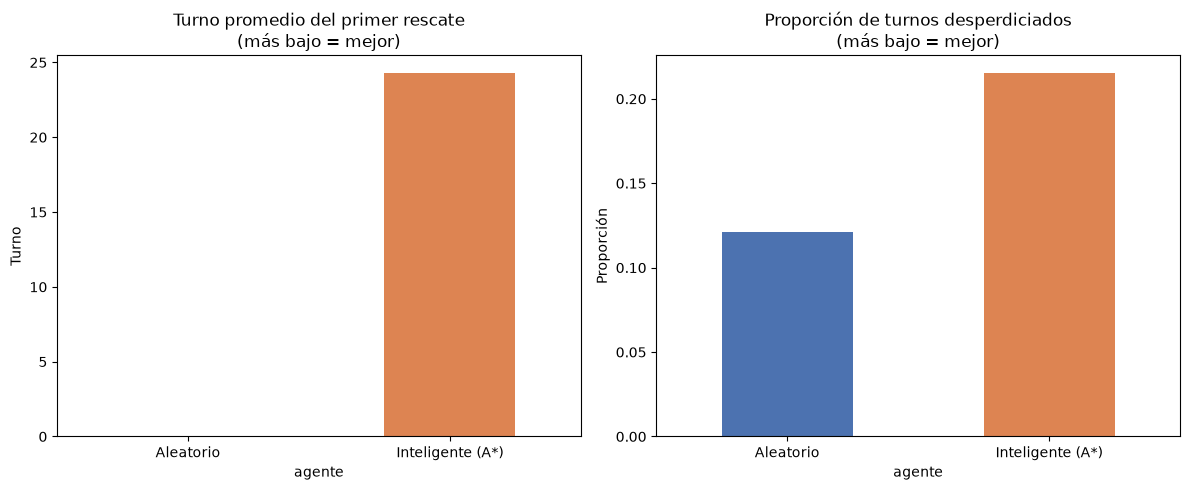

In [33]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

resumen["turno_primer_rescate"].plot(kind = "bar", ax = axes[0], color = ["#4C72B0", "#DD8452"])
axes[0].set_title("Turno promedio del primer rescate\n(más bajo = mejor)")
axes[0].set_ylabel("Turno")
axes[0].tick_params(axis = "x", rotation = 0)

resumen["desperdicio_por_turno"].plot(kind = "bar", ax = axes[1], color = ["#4C72B0", "#DD8452"])
axes[1].set_title("Proporción de turnos desperdiciados\n(más bajo = mejor)")
axes[1].set_ylabel("Proporción")
axes[1].tick_params(axis = "x", rotation = 0)

plt.tight_layout()
plt.show()

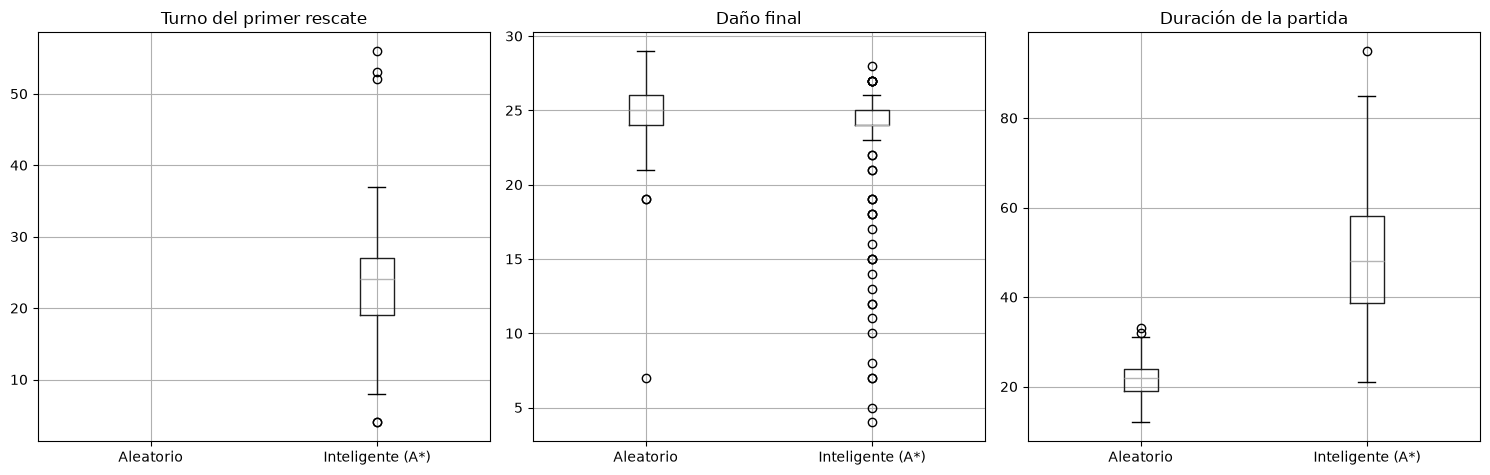

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, titulo in zip(axes, 
                            ["turno_primer_rescate", "danio_final", "turnos_jugados"],
                            ["Turno del primer rescate", "Daño final", "Duración de la partida"]):
    df.boxplot(column=col, by="agente", ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("")

plt.suptitle("")
plt.tight_layout()
plt.show()

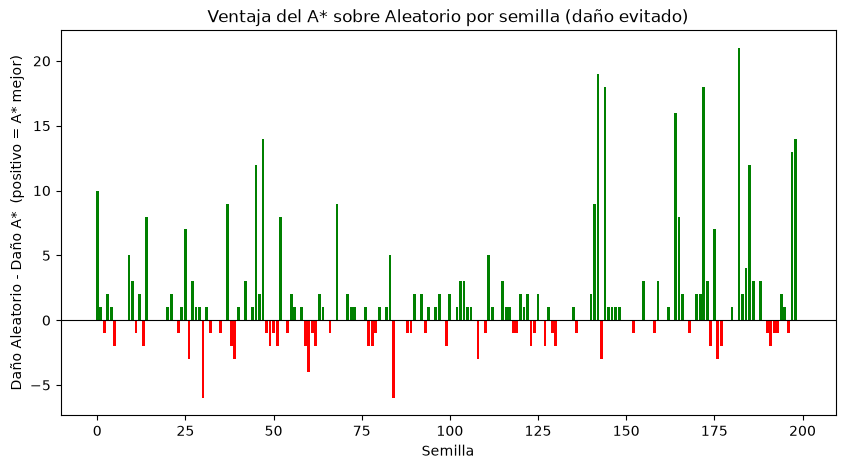

In [35]:
pivot = df.pivot(index="seed", columns="agente", values="danio_final")
diferencia = pivot["Aleatorio"] - pivot["Inteligente (A*)"]

plt.figure(figsize=(10, 5))
colors = ["green" if d > 0 else "red" for d in diferencia]
plt.bar(diferencia.index, diferencia.values, color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Ventaja del A* sobre Aleatorio por semilla (daño evitado)")
plt.xlabel("Semilla")
plt.ylabel("Daño Aleatorio - Daño A*  (positivo = A* mejor)")
plt.show()